In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", cmap="gray", size=(5,5)):
    plt.figure(figsize=size)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

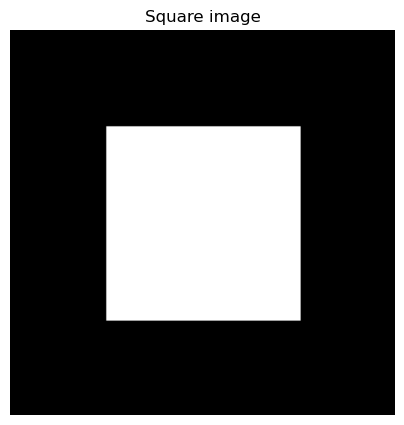

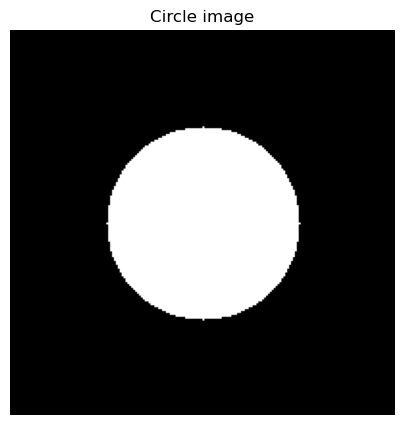

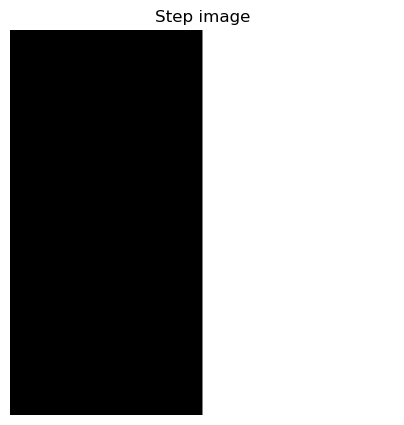

In [2]:
# Black background
img_square = np.zeros((200, 200), dtype=np.uint8)
img_circle = np.zeros((200, 200), dtype=np.uint8)
img_step = np.zeros((200, 200), dtype=np.uint8)

# Draw shapes
cv2.rectangle(img_square, (50, 50), (150, 150), 255, -1)
cv2.circle(img_circle, (100, 100), 50, 255, -1)

# Create a step image: left side dark, right side bright
img_step[:, :100] = 50
img_step[:, 100:] = 220

show(img_square, "Square image")
show(img_circle, "Circle image")
show(img_step, "Step image")

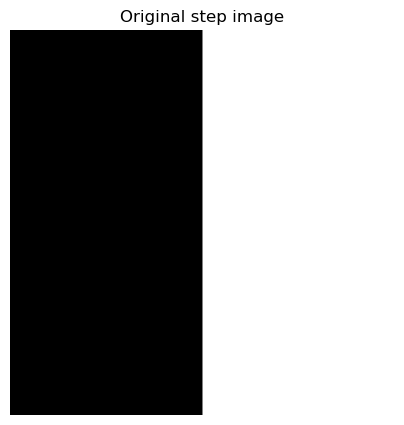

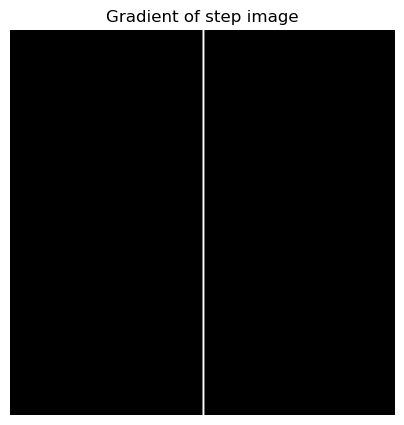

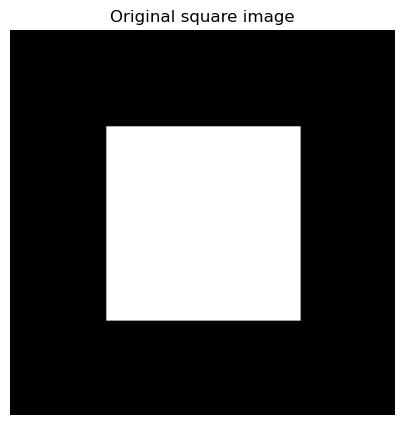

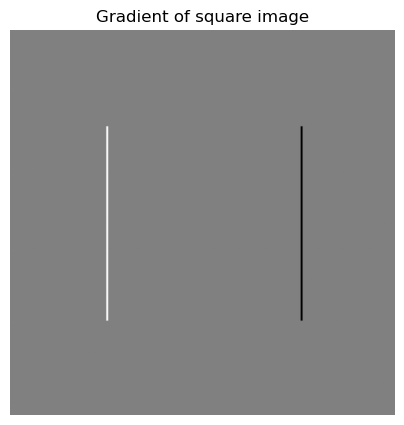

In [3]:
# Simple horizontal gradient kernel
kernel_x = np.array([[-1, 1]], dtype=np.float32)

grad_step = cv2.filter2D(img_step, cv2.CV_64F, kernel_x)
grad_square = cv2.filter2D(img_square, cv2.CV_64F, kernel_x)

show(img_step, "Original step image")
show(grad_step, "Gradient of step image")
show(img_square, "Original square image")
show(grad_square, "Gradient of square image")

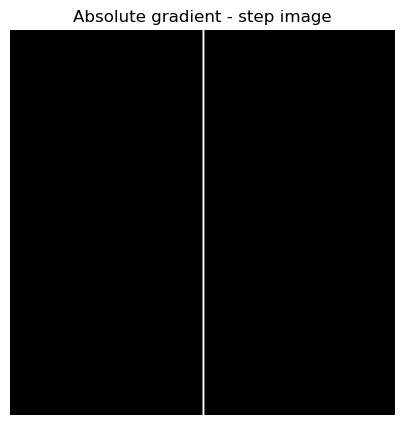

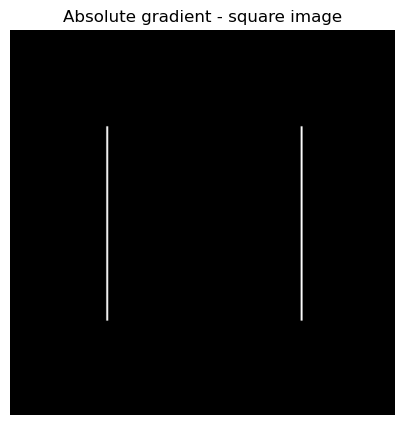

In [4]:
# Convert the gradient to absolute values for easier display
grad_square_abs = np.abs(grad_square).astype(np.uint8)
grad_step_abs = np.abs(grad_step).astype(np.uint8)

show(grad_step_abs, "Absolute gradient - step image")
show(grad_square_abs, "Absolute gradient - square image")

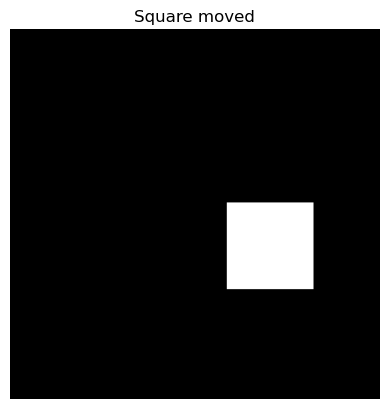

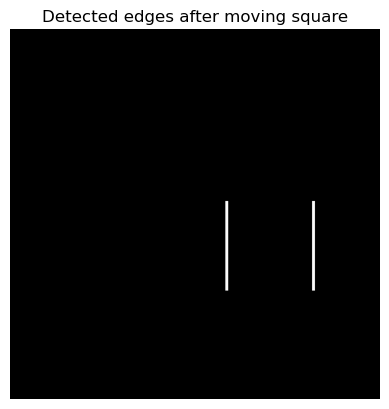

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def show(img, title="Image"):
    plt.figure()
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Create black image
img = np.zeros((256,256), dtype=np.uint8)

# CHANGE POSITION HERE
img[120:180, 150:210] = 255   # square moved to another location

show(img, "Square moved")

# Gradient (x direction)
grad_square = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)

grad_square_abs = np.abs(grad_square).astype(np.uint8)

show(grad_square_abs, "Detected edges after moving square")

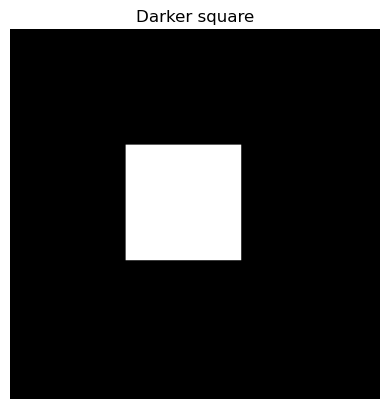

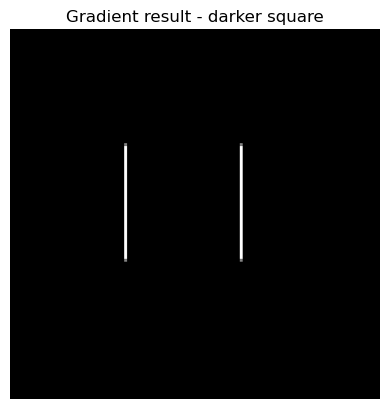

In [10]:
img = np.zeros((256,256), dtype=np.uint8)

# darker square
img[80:160, 80:160] = 120

show(img, "Darker square")

grad_square = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)

grad_square_abs = np.abs(grad_square).astype(np.uint8)

show(grad_square_abs, "Gradient result - darker square")

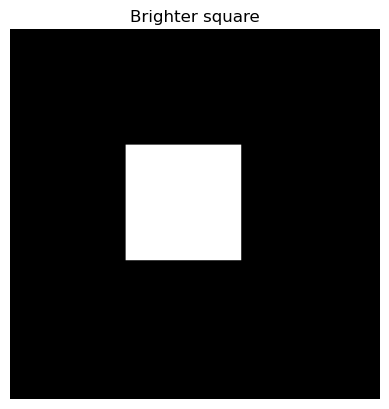

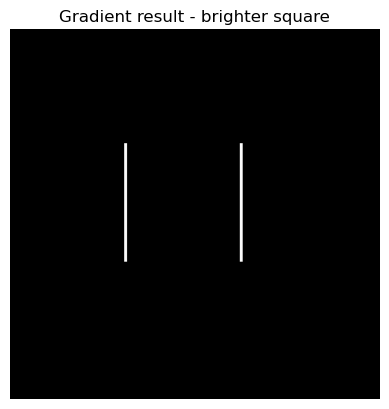

In [11]:
img = np.zeros((256,256), dtype=np.uint8)

# brighter square
img[80:160, 80:160] = 255

show(img, "Brighter square")

grad_square = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)

grad_square_abs = np.abs(grad_square).astype(np.uint8)

show(grad_square_abs, "Gradient result - brighter square")

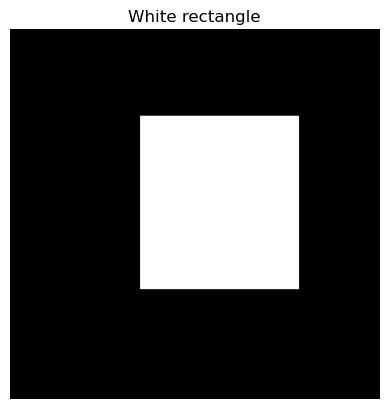

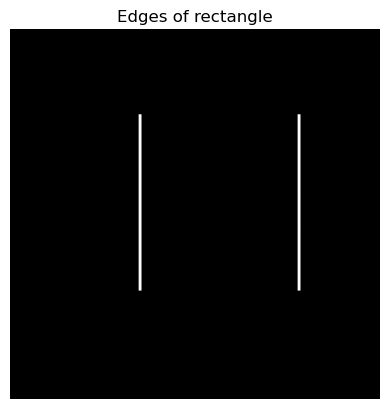

In [12]:
img = np.zeros((256,256), dtype=np.uint8)

# rectangle instead of square
img[60:180, 90:200] = 255

show(img, "White rectangle")

grad_square = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)

grad_square_abs = np.abs(grad_square).astype(np.uint8)

show(grad_square_abs, "Edges of rectangle")

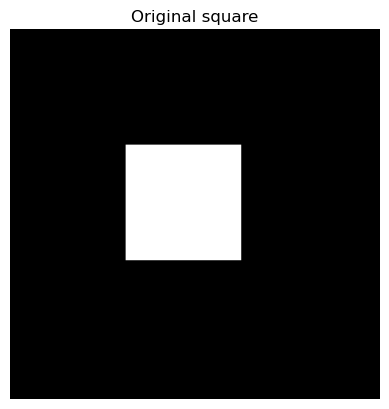

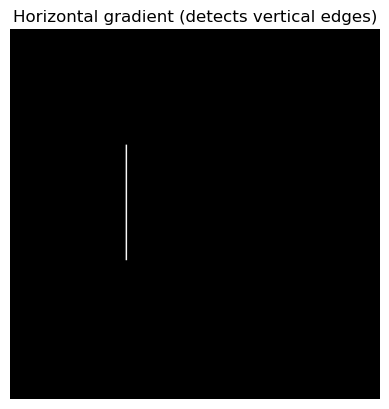

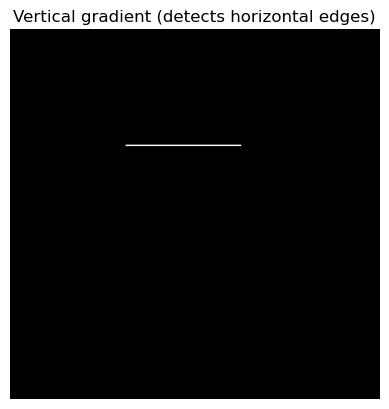

In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def show(img, title="Image"):
    plt.figure()
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Create square image
img = np.zeros((256,256), dtype=np.uint8)
img[80:160, 80:160] = 255

show(img, "Original square")

# Horizontal gradient kernel
kernel_x = np.array([[-1, 1]], dtype=np.float32)

# Vertical gradient kernel
kernel_y = np.array([[-1], [1]], dtype=np.float32)

# Apply kernels
grad_x = cv2.filter2D(img, -1, kernel_x)
grad_y = cv2.filter2D(img, -1, kernel_y)

show(np.abs(grad_x), "Horizontal gradient (detects vertical edges)")
show(np.abs(grad_y), "Vertical gradient (detects horizontal edges)")

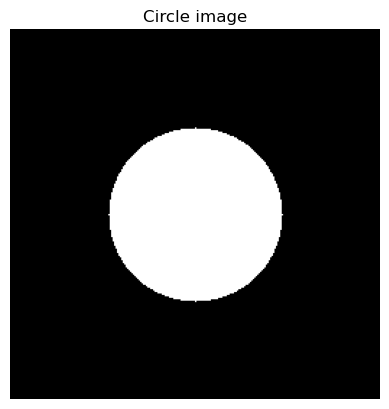

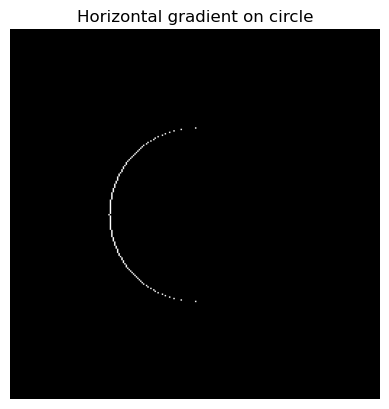

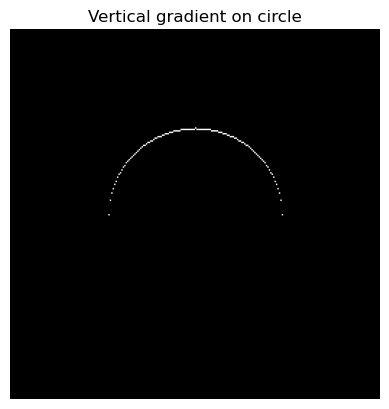

In [14]:
# Create circle image
circle = np.zeros((256,256), dtype=np.uint8)
cv2.circle(circle, (128,128), 60, 255, -1)

show(circle, "Circle image")

# Apply gradients
grad_x_circle = cv2.filter2D(circle, -1, kernel_x)
grad_y_circle = cv2.filter2D(circle, -1, kernel_y)

show(np.abs(grad_x_circle), "Horizontal gradient on circle")
show(np.abs(grad_y_circle), "Vertical gradient on circle")

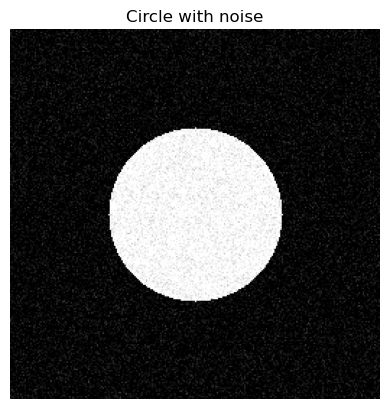

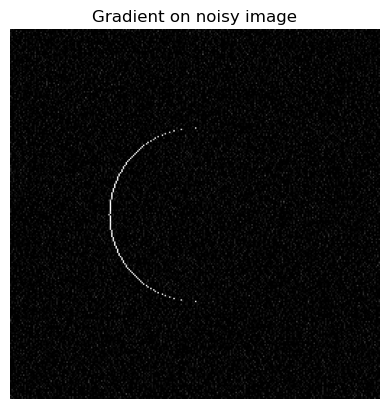

In [15]:
# Add noise
noise = np.random.normal(0, 20, (256,256))
noisy_image = circle + noise

# convert to uint8
noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)

show(noisy_image, "Circle with noise")

# Apply gradient
grad_noise = cv2.filter2D(noisy_image, -1, kernel_x)

show(np.abs(grad_noise), "Gradient on noisy image")

In [16]:
def simple_gradient(image, direction='x'):
    
    if direction == 'x':
        kernel = np.array([[-1, 1]], dtype=np.float32)
        
    elif direction == 'y':
        kernel = np.array([[-1], [1]], dtype=np.float32)
        
    grad = cv2.filter2D(image, -1, kernel)
    
    return grad

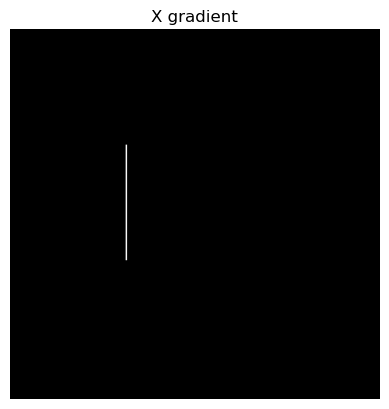

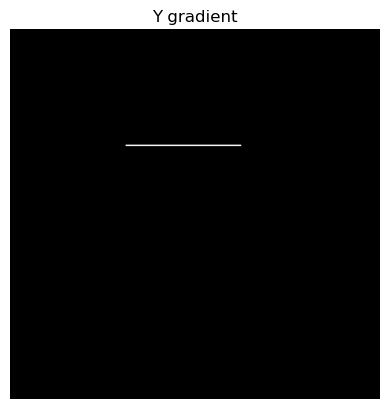

In [17]:
gx = simple_gradient(img, 'x')
gy = simple_gradient(img, 'y')

show(np.abs(gx), "X gradient")
show(np.abs(gy), "Y gradient")

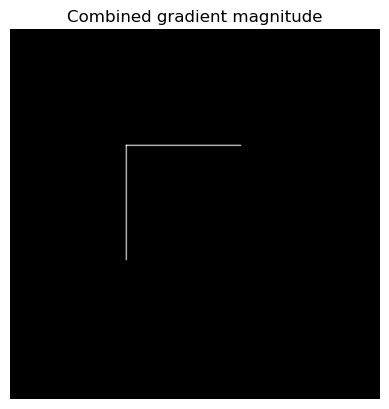

In [18]:
gx = simple_gradient(img, 'x')
gy = simple_gradient(img, 'y')

magnitude = np.sqrt(gx**2 + gy**2)

show(magnitude, "Combined gradient magnitude")